# pre amble

In [6]:
from tqdm import tqdm
from matplotlib import rc
import seaborn as sns
custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": "k",
    "lines.markeredgewidth": 0.3,
    "figure.dpi": 200,
    "text.usetex": False,       # breaks sometimes 
    "font.family": "serif",
    "font.size": 20,
}

sns.set_theme(context = "notebook", style="ticks", rc=custom_params)

BlueUB = (0, 157/255, 224/255)
BrownUB = (68/255, 58/255, 49/255)

In [2]:
'''
MERSENNE-TWISTER ALGORiTHM IN PYTHON
Copyright (c) 2019 yinengy
'''
import time
import numpy as np

# Coefficients for MT19937
(w, n, m, r) = (32, 624, 397, 31)
a = 0x9908B0DF
(u, d) = (11, 0xFFFFFFFF)
(s, b) = (7, 0x9D2C5680)
(t, c) = (15, 0xEFC60000)
l = 18
f = 1812433253

# Make a arry to store the state of the generator
MT = [0 for i in range(n)]
index = n+1
lower_mask = 0x7FFFFFFF #(1 << r) - 1 // le nombre binaire de r
upper_mask = 0x80000000 # w bits les plus bas de (pas lower_mask)

# Initialize the generator from a seed
def mt_seed(seed):
    # global index
    # index = n
    MT[0] = seed
    for i in range(1, n):
        temp = f * (MT[i-1] ^ (MT[i-1] >> (w-2))) + i
        MT[i] = temp & 0xffffffff

# Extract a tempered value based on MT[index]
# Calling twist() every n numbers
def random_mersenne_twister():
    global index
    if index >= n:
        twist()
        index = 0

    y = MT[index]
    y = y ^ ((y >> u) & d)
    y = y ^ ((y << s) & b)
    y = y ^ ((y << t) & c)
    y = y ^ (y >> l)

    index += 1
    return (y & 0xffffffff)/4294967296

def seed_random(seed):
    """
    Choose a random seed or a fixe seed.
    :return: none
    """
    if seed == 0:
        mt_seed(int(time.time()*1e7)) # generates a seed on the time in 10^-7 seconds
    else:
        mt_seed(int(seed))

# Generate the next n values from the series x_i
def twist():
    for i in range(0, n):
        x = (MT[i] & upper_mask) + (MT[(i+1) % n] & lower_mask)
        xA = x >> 1
        if (x % 2) != 0:
            xA = xA ^ a
        MT[i] = MT[(i + m) % n] ^ xA

'''
BOX-MULLER ALGORITHM IN PYTHON
'''
def random_gaussian():
    """
    :return: Gaussian random number of 0 mean and 1 standard deviation.
    """
    w = 2.0
    while (w >= 1.0):
        # genère une seed sur le temp en 10^-7 second
        mt_seed(int(time.time()*1e7))
        x1 = 2.0 * random_mersenne_twister() - 1.0
        x2 = 2.0 * random_mersenne_twister() - 1.0
        w = x1 * x1 + x2 * x2
    w = ((-2.0 * np.log(w)) / w) ** 0.5
    return x1 * w



In [3]:
'''
Elodie Millan
June 2020
(Update 2023)
---------
Numerical simulation of Bulk Brownian motion.
'''

import numpy as np
import time

class Langevin:
    def __init__(self, dt, Nt, a, eta0=0.001, T=300, X0=0, gravity=False, signe="+"):
        """
        Constructor : Initialisation.

        :param dt: Numerical time step [s].
        :param Nt: Number of point.
        :param a: Particle radius [m].
        :param eta0: Fluid viscosity (default = 0.001 [Pa/s]).
        :param T: Temperature (default = 300 [K]).
        :param X0: Initial position (default = 0 [m]).
        :param gravity : Boolean to activate gravity (default = False).
        :param signe : String "+" or "-" to indicate orientation of gravity (Default = "+").
        """
        self.dt = dt
        self.Nt = int(Nt)
        self.a = a
        self.eta0 = eta0
        self.T = T
        self.Xn = np.zeros(Nt)
        self.Xn[0] = X0
        self.gravity = gravity
        if signe=="+":
            self.pm = +1
        else:
            self.pm = -1

        self.lB = 526e-9   #  ?
        self.kb = 1.38e-23 # boltzman constant
        self.gamma = 6 * np.pi * self.eta0 * self.a # stokes friction
        self.D0 = (self.kb * self.T) / (self.gamma) # diffusion coefficient
        self.t = np.arange(Nt) * dt                 # time_array

    def trajectory(self, output=False):
        """
        @param output: Boolean, if True return Xn (default = False).
        @return: Trajectory Xn.
        """
        for n in range(self.Nt-1):
            Wn = random_gaussian()
            if self.gravity:
                self.U = self.pm*(self.kb*self.T)/self.lB / self.gamma # Signe of speed from force given by lB in input.
            else:
                self.U = 0
            self.Xn[n+1] = self.Xn[n] + self.U*self.dt + np.sqrt(2*self.D0 * self.dt)* Wn 
        if output:
            return self.Xn

    '''
    Analysis Methods
    '''
    def MSD(self):
        """
        This is an MSD function, could re-write this if need be
        @return: (< [Xn(t+tau) - Xn(t)]^2 >, tau).
        """
        self.list_k_tau = np.array([], dtype=int) # Liste des entiers k tel que tau = k*dt
        for k in range(len(str(self.Nt)) - 1):
            # Construit 10 points par décades
            self.list_k_tau = np.concatenate(
                (
                    self.list_k_tau,
                    np.arange(10 ** k, 10 ** (k + 1), 10 ** k, dtype=int),
                )
            )

        x = self.Xn
        NumberOfMSDPoint = len(self.list_k_tau)
        self.MSD = np.zeros(NumberOfMSDPoint)
        for n, k in enumerate(self.list_k_tau):
            if k == 0:
                self.MSD[n] = 0
                continue
            self.MSD[n] = np.mean((x[k:] - x[0:-k]) ** 2)

        return self.list_k_tau*self.dt, self.MSD


# Random Number Generator - $w(t)$

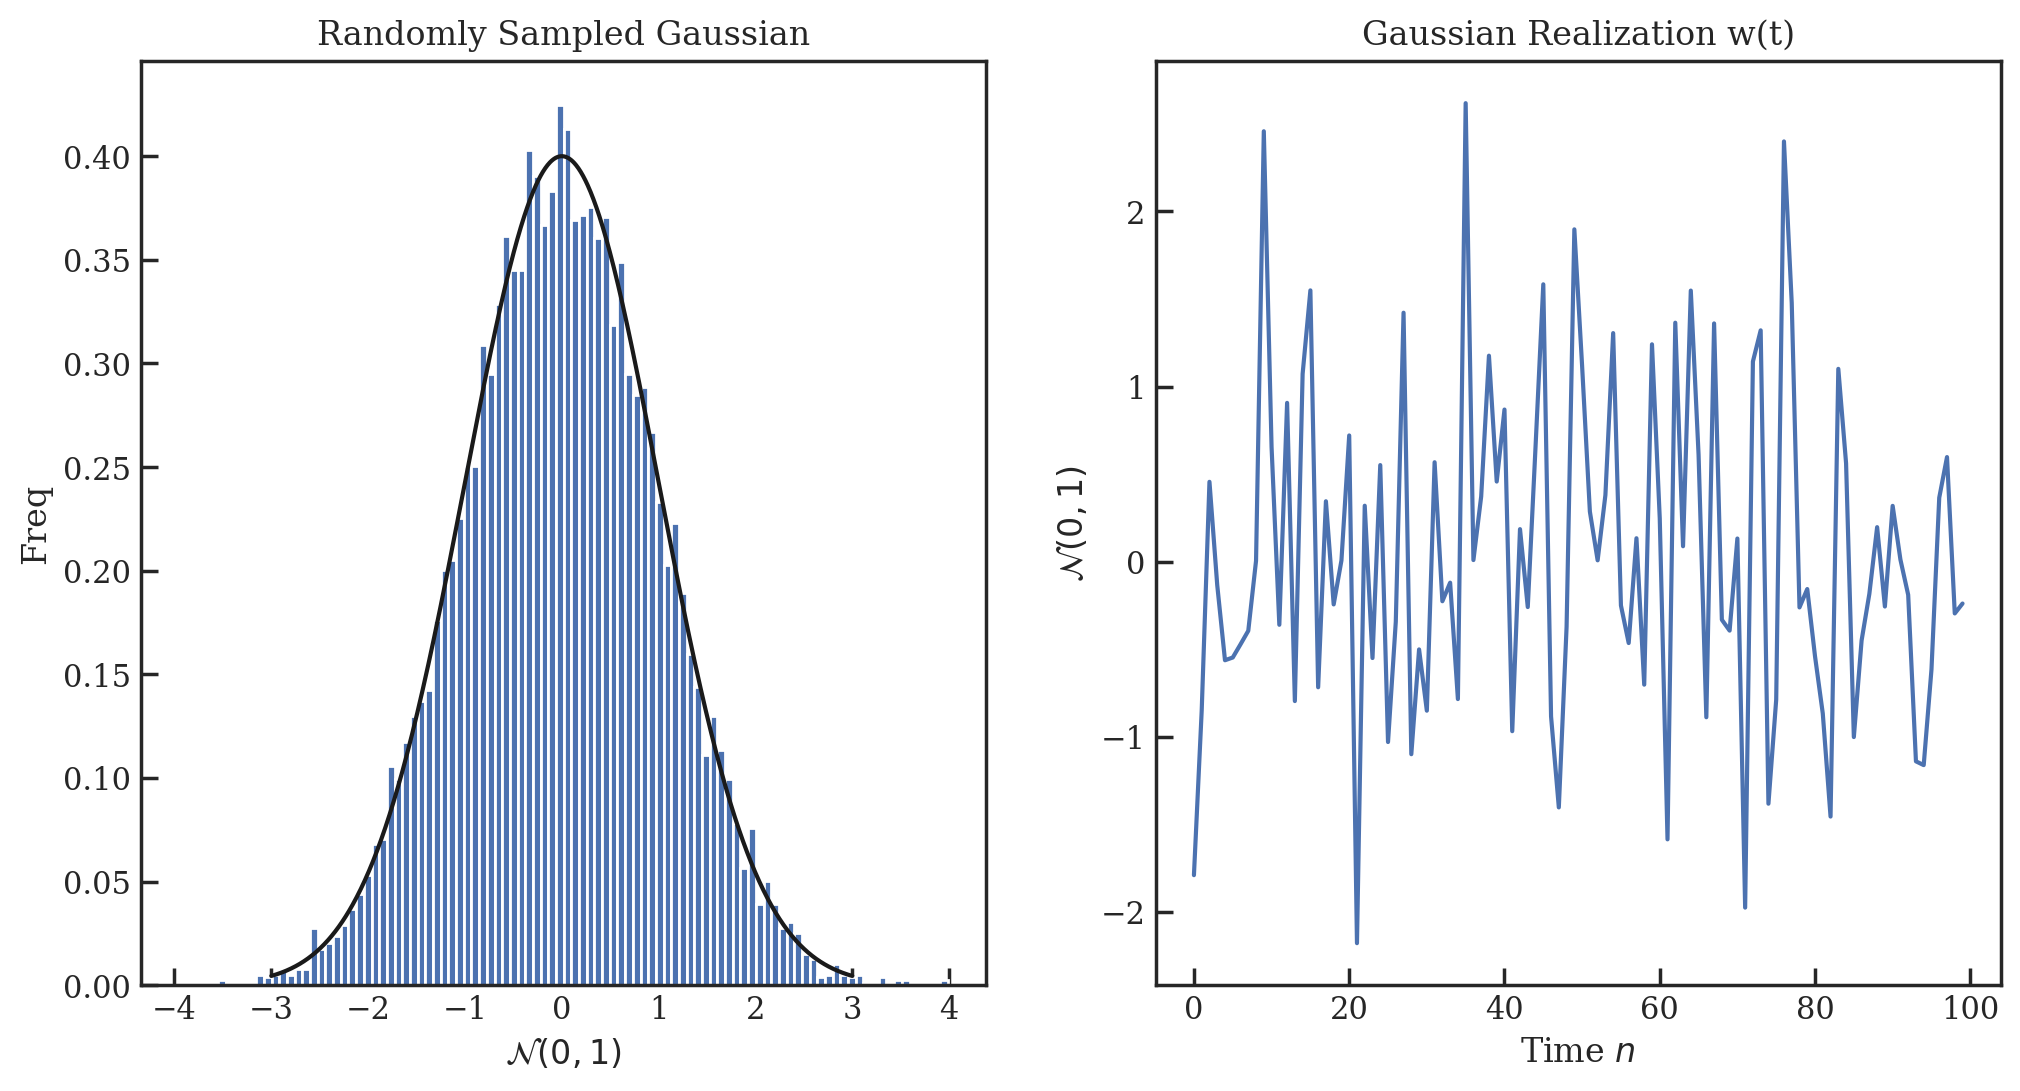

In [7]:
import matplotlib.pyplot as plt
numbers = [random_gaussian() for i in range(10000)]

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))

sigma =1
x = np.linspace(-3 * sigma, 3 * sigma, 1000)
p_gauss = 1 / (np.sqrt(2 * np.pi) * 1) * np.exp(-x ** 2 / (2 * sigma ** 2))
ax1.hist(numbers,density=True,bins=100)
ax1.plot(x, p_gauss / np.trapezoid(p_gauss, x), "k-")
ax1.set_xlabel(r'$\mathcal{N}(0,1)$')
ax1.set_ylabel('Freq')
ax1.set_title('Randomly Sampled Gaussian')

ax2.set_title('Gaussian Realization w(t)')
ax2.plot(numbers[:100])
ax2.set_xlabel('Time $n$')
ax2.set_ylabel(r'$\mathcal{N}(0,1)$')

plt.show()

# Free 3D Langevin Equation

In [8]:
dt = 1/300 #[s]
N  = int(2000) # frame number
radius  = 100e-9

brown = Langevin(dt, N, radius, eta0=0.001, T = 293)

In [9]:
# 3D trajectory
brown.trajectory()
trajx = brown.Xn * 10**6
brown.trajectory()
trajy = brown.Xn * 10**6
brown.trajectory()
trajz = brown.Xn * 10**6
# time array 
t_arr = brown.t

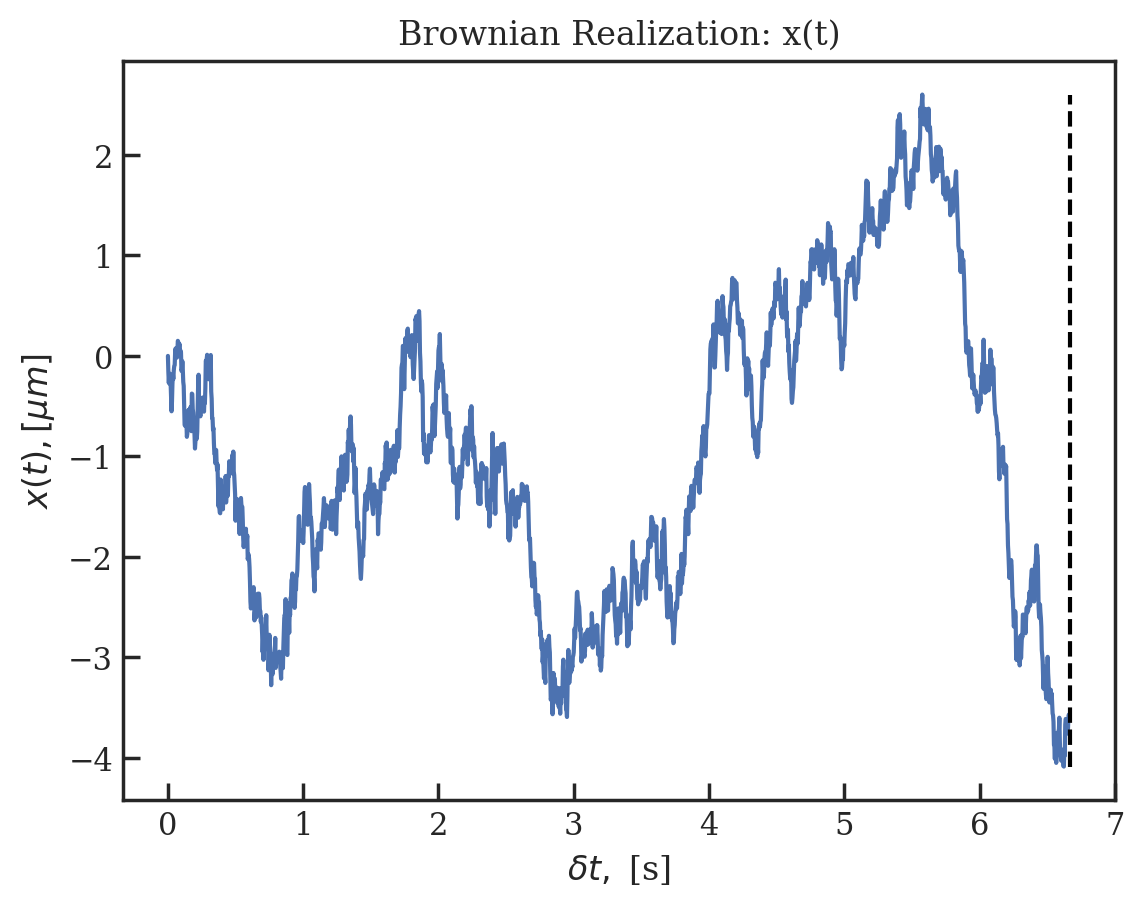

In [12]:
#print(dt * N)
fig1 = plt.figure()
ax1 = fig1.add_subplot()
ax1.plot(t_arr, trajx)
ax1.set_ylabel(r'$x(t), [\mu m]$')
ax1.set_xlabel(r'$\delta t,$ [s]')
ax1.vlines(dt * N, min(trajx), max(trajx), color='black', linestyles='dashed')
ax1.set_title(r'Brownian Realization: x(t)')
plt.show()

100%|██████████| 100/100 [00:26<00:00,  3.74it/s]


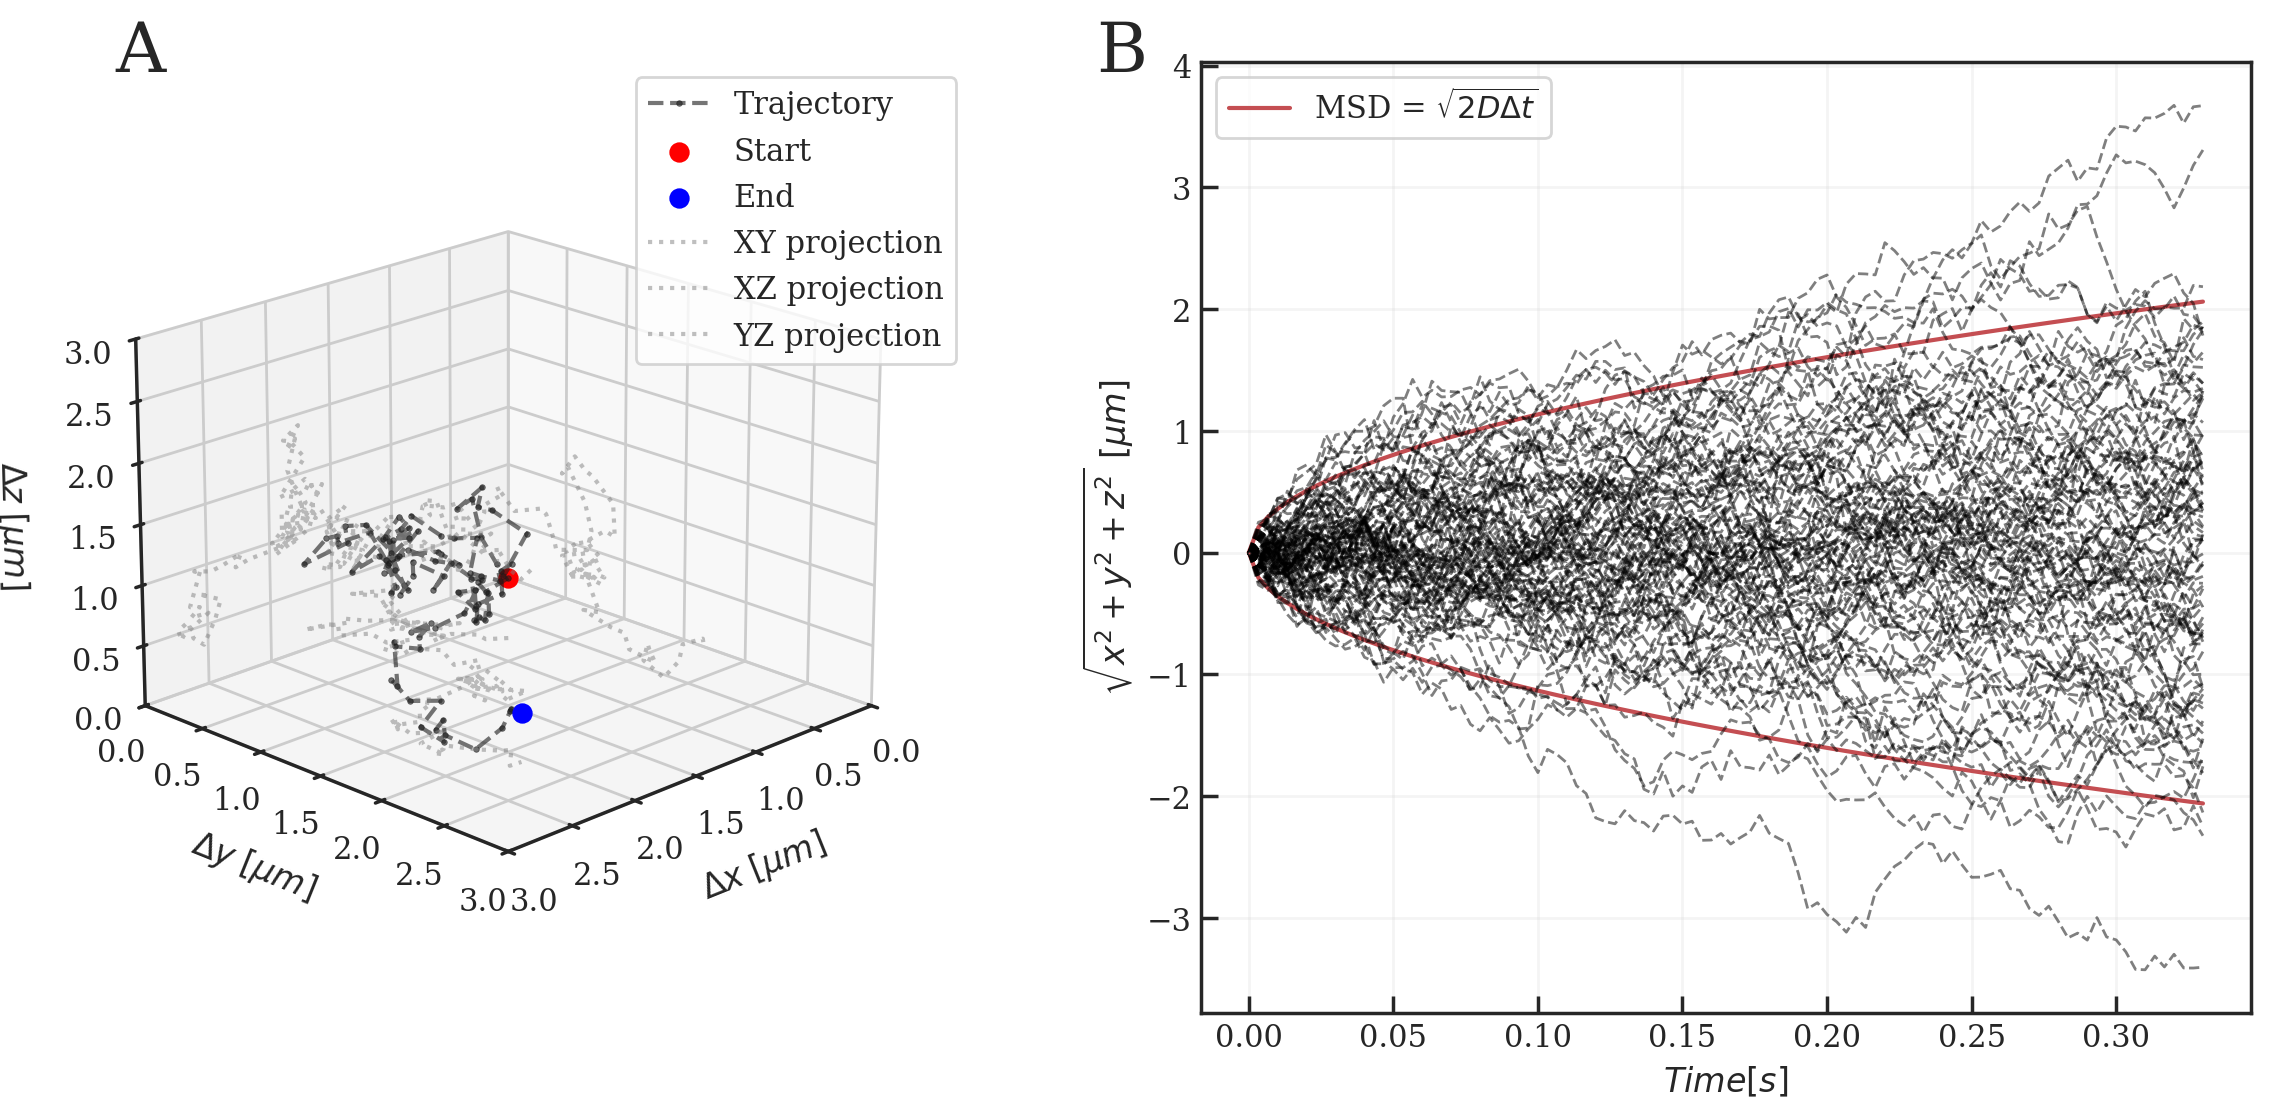

In [14]:

x = trajx[:100]
y = trajy[:100]
z = trajz[:100]

fig = plt.figure(dpi=200, figsize=(12,6))
ax1 = fig.add_subplot(121, projection='3d')

ax1.set_xlim3d(0, 3)
ax1.set_ylim3d(0, 3)
ax1.set_zlim3d(0, 3)

# Main trajectory
ax1.plot3D(x, y, z,
           color='k',
           linestyle='--',
           marker='o',
           markersize=2,
           alpha=0.6,
           label='Trajectory')

# Start and end points
ax1.scatter(x[0], y[0], z[0], color='red', s=40, label='Start')
ax1.scatter(x[-1], y[-1], z[-1], color='blue', s=40, label='End')

# --- Projections ---
# XY plane (z = min(z))
z_min = np.min(z)
ax1.plot3D(x, y, z_min,
           color='gray',
           linestyle=':',
           alpha=0.5,
           label='XY projection')

# XZ plane (y = min(y))
y_min = np.min(y)
ax1.plot3D(x, y_min, z,
           color='gray',
           linestyle=':',
           alpha=0.5,
           label='XZ projection')

# YZ plane (x = min(x))
x_min = np.min(x)
ax1.plot3D(x_min, y, z,
           color='gray',
           linestyle=':',
           alpha=0.5,
           label='YZ projection')

# Labels
ax1.set_xlabel(r'$\Delta x\;[\mu m]$', labelpad=10)
ax1.set_ylabel(r'$\Delta y\;[\mu m]$', labelpad=10)
ax1.set_zlabel(r'$\Delta z\;[\mu m]$', labelpad=10)

# Aspect ratio (important for interpretation)
ax1.set_box_aspect(None, zoom=0.85)

# View angle (optional but helps readability)
ax1.view_init(elev=20, azim=45)

# Legend
ax1.legend(loc='upper right')

# ----------------------------------------
# AXIS 2
# ----------------------------------------

ax2 = fig.add_subplot(122)
ax2.set_aspect('auto')
#ax2.set_aspect(0.03)


# plot theoretical displacement histogram
def distFunc(t, D):
    return np.sqrt(6 * D * t)
lag = np.arange(0, 100, 1) 
pos_dist = distFunc(dt * lag, brown.D0) * 10**6

ax2.plot(dt * lag, pos_dist, 'r' , label=r'MSD = $\sqrt{2D\Delta t}$')
ax2.plot(dt * lag, -pos_dist, 'r')
ax2.grid(alpha=0.2)

# loop over particles
for i in tqdm(range(100)):
    brown.trajectory()
    trajx = brown.Xn * 10**6
    # get the thingy
    x1 = np.array(trajx[:100])
    #free_sim.plotFlattenedTrajectory(fig, ax2, particle_index=i, x_max=100)
    #abs_pos = np.sqrt(x1**2 + y1**2 + z1**2) - np.sqrt(x1[0]**2 + y1[0]**2 + z1[0]**2)
    #print(np.shape(abs_pos))
    # Plot the trajectory
    ax2.plot(dt * lag, x1, color='black', linestyle='dashed', alpha=0.5, linewidth=1)
    #ax2.plot(dt * lag, y1, color='black', linestyle='dashed', alpha=0.5, linewidth=1)
    #ax2.plot(dt * lag, z1, color='black', linestyle='dashed', alpha=0.5, linewidth=1)

    ax2.plot(0, x1[0], 'ro', markersize=1)
# end loop

ax2.legend()
ax2.set_ylabel(r'$\sqrt{x^2 + y^2 + z^2}$ $[\mu m]$')
ax2.set_xlabel(r'$Time [s]$')

ax1.text2D(0.1, 0.99, "A", transform=ax1.transAxes,
           fontsize=25)

ax2.text(-0.1, 0.99, "B", transform=ax2.transAxes,
           fontsize=25)
y_fig = 0.95  # adjust this to match the height of your A/B labels

line = plt.Line2D([0.05, 0.95], [y_fig, y_fig],
                  transform=fig.transFigure,
                  color='black',
                  linestyle='-',
                  linewidth=1,
                  alpha=0.7)
#fig.add_artist(line)                 # this ads a ling
plt.tight_layout()
#savefig('free_diff_visual')


# Linear, Confined Langevin with Euler Scheme


In [118]:
from scipy import interpolate

# class here
pi = np.pi

# Helper Functions
def gamma_x_tot(zn, a, eta0, H):
    """
    [Libshaber]
    @return: Parallel mobility of the particle depending of Zn due to walls.
    """
    # Wall of the top at z = +Hp
    zn_T = a / ((H-zn) + a)
    gam_x_T = (
        6.
        * pi
        * a
        * eta0
        *
        (
            1.
            - 9./16. * zn_T
            + 1./8. * zn_T**3.
            - 45./256. * zn_T**4.
            - 1./16. * zn_T** 5.
        )
        ** (-1)
    )
    # Wall of the bottom at z = -Hp
    zn_B = a / ((H+zn) + a)
    gam_x_B = (
        6
        * pi
        * a
        * eta0
        * (
            1.
            - 9./16. * zn_B
            + 1./8. * zn_B**3
            - 45./256. * zn_B**4
            - 1./16. * zn_B** 5
        )
        ** (-1)
    )
    gam_0 = 6 * pi * a * eta0

    return (gam_x_T + gam_x_B - gam_0)

def gamma_z_tot(zn, a, eta0, H):
    """
    [Padé approximation]
    @return: Perpendicular mobility of the particle depending of Zn due to walls.
    """
    # Wall of the top at z = +Hp
    gam_z_T = (
        6
        * pi
        * a
        * eta0
        * (
            (
                (6 * (H-zn)**2 + 9*a*(H-zn) + 2*a**2)
                / (6 * (H-zn)**2 + 2*a*(H-zn))
            )
        )
    )
    # Wall of the bottom at z = -Hp
    gam_z_B = (
        6
        * pi
        * a
        * eta0
        * ((6*(H+zn)**2 + 9*a*(H+zn) + 2*a**2)/ (6 * (H+zn)**2 + 2*a*(H+zn)))
    )
    gam_0 = 6 * pi * a * eta0

    return (gam_z_T + gam_z_B - gam_0)

def Noise(gamma, kBT):
    """
    :return: Noise amplitude of brownian motion.
    """
    noise = np.sqrt(2 * kBT / gamma)
    return noise

def next_Xn(xn, zn, Wn, dt, a, eta0, kBT, H):
    """
    :return: Parallel position at time tn+dt
    """
    gamma = gamma_x_tot(zn, a, eta0, H)
    return xn + Noise(gamma, kBT) * Wn * np.sqrt(dt)

def Dprime_z(zn, kBT, eta0, a, H):
    """
    :return: Spurious force to correct overdamping. (Author Dr. Maxime Lavaud).
    """
    eta_B_primes = -(a * eta0 * (2 * a ** 2 + 12 * a * (H + zn) + 21 * (H + zn) ** 2)) / (
        2 * (H + zn) ** 2 * (a + 3 * (H + zn)) ** 2
    )

    eta_T_primes = (
        a
        * eta0
        * (2 * a ** 2 + 12 * a * (H-zn) + 21 * (H-zn) ** 2)
        / (2 * (a + 3*H - 3*zn) ** 2*(H-zn) ** 2)
    )

    eta_eff_primes = eta_B_primes + eta_T_primes

    eta_B = eta0 * (6*(H+zn)**2 + 9*a*(H+zn) + 2*a**2) / (6*(H+zn)**2 + 2*a*(H+zn))
    eta_T = eta0 * (6*(H-zn)**2 + 9*a*(H-zn) + 2*a**2) / (6*(H-zn)**2 + 2*a*(H-zn))

    eta_eff = eta_B + eta_T - eta0

    return - kBT / (6*pi*a) * eta_eff_primes / eta_eff**2

def Forces(zn, H, kBT, B, lD, lB):
    """
    @return: Total extern force on particle (without friction).
    """
    # double wall potential - derivative of the potential
    #Felec = B * (1/np.abs(H+zn)**2 + 1/np.abs(H-zn)**2)
    Felec = B * kBT/lD * np.exp(-H/lD) * (np.exp(-zn/lD) - np.exp(zn/lD))
    Fgrav = 0#-kBT/lB 
    return  Felec + Fgrav

def next_Zn(zn, Wn, dt, a, eta0, kBT, H, lB, lD, B):
    """
    @return: Perpendicular position Zn+1 at time tn+dt
    """
    gamma = gamma_z_tot(zn, a, eta0, H)
    zn = zn + Dprime_z(zn, kBT, eta0, a, H )*dt \
         + Forces(zn, H, kBT, B, lD, lB)*dt /gamma \
         + Noise(gamma, kBT) * Wn * np.sqrt(dt)

    if zn < -(H):
        zn = -2*H - zn
    if zn > H:
        zn =  2*H - zn

    return zn

# Trajecotry Compute
def trajectory_python(Nt, Nt_sub, Rn, dt, a, eta0, kBT, H, lB, lD, B):
    """
    @param Nt: Number of points.
    @param Nt_sub: Modulation of the number of points recorded.
                Exemple: if Nt_sub=10, then points are calculated every 10 steps.
    @param Rn: Total trajectory vector of size [2, Nt] (m, m).
    @param dt: Numerical time step (s).
    @param a: Particle radius (m).
    @param eta0: Fluid viscodity (Pa.s).
    @param kBT: Thermal energie with kB: Boltzman constante et T: Temperature (K).
    @param H: 2Hp = 2H + 2a, is the gap between the two walls.
    @param lB: Boltzman length.
    @param lD: Debye length.
    @param B: Dimensionless constant characteristic of surface charge interactions.
    @return: Trajectory (Xn, Zn) for all time [0,Nt]*dt
    """
    Xn = Rn[0,0]
    Zn = Rn[1,0]
    seed_random(0)

    for n in tqdm(range(1, Nt)):
        for j in range(0, Nt_sub):
            Xn = next_Xn(Xn, Zn, random_gaussian(), dt, a, eta0, kBT, H)
            Zn = next_Zn(Zn, random_gaussian(), dt, a, eta0, kBT, H, lB, lD, B)

        Rn[0,n] = Xn
        Rn[1,n] = Zn

    return Rn

#  Double Wall Langevin Class
class DoubleWallsLangevin( Langevin ):
    def __init__(self, dt, Nt, a, H, lD, lB,
                 B=4.8, Nt_sub=1, eta0=0.001, T=300, R0=None):
        """
        :param dt: Numerical time step (s).
        :param Nt: Number of points.
        :param a: Particle radius (m).
        :param H: 2Hp = 2H + 2, is the gap between the two walls.
        :param lD: Debye length (m). (screening)
        :param lB: Boltzman length (m). (idk what this is)
        :param B: Dimensionless constant characteristic of surface charge interactions.
        :param Nt_sub: Modulation of the number of points recorded.
                       example: if Nt_sub=10, then points are calculated every 10 steps.
        :param eta0: Fluid viscosity (default = 0.001 (Pa.s)).
        :param T: Temperature of the system (default = 300 (K)).
        :param R0: Initial position vector |X0, Z0|,
                   (default = |0,Zeq| with Zeq shoot on equilibrium distribution Peq(z) (m,m)).
        """
        super().__init__(dt, Nt, a, eta0, T)
        self.a = a
        self.H = H
        self.Nt_sub = Nt_sub
        self.eta0 = eta0
        self.T = T
        self.kBT = 1.38e-23*self.T
        self.Hp = self.H + self.a
        self.D0 = self.kBT/(6*np.pi*self.eta0*self.a)
        self.lD = lD
        self.B = B
        self.lB = lB
        self.sample_f = self.sample()
        self.R0 = R0
        if R0 == None:
            # Random selection of altitude Z0
            # on the equilibrium distribution P_eq(z)
            self.R0 = (0.0, self.return_samples(1))

        del self.t #to save some space memory
        # because it could be compute with sel.dt and self.Nt

    def trajectory(self, output=False):
        """
        :param output: Boolean - if True, return (Default = False).
        :return: (X_n, Z_n) trajectory.
        """
        Rn = np.zeros((2, self.Nt))
        # Initial condition.
        Rn[0,0] = self.R0[0]
        Rn[1,0] = self.R0[1]

        Rn = np.asarray(trajectory_python(self.Nt, self.Nt_sub,
                                   Rn,
                                   self.dt,
                                   self.a, self.eta0,
                                   self.kBT, self.H, self.lB, self.lD, self.B))

        self.Xn = Rn[0,:]
        self.Zn = Rn[1,:]
        if output:
            return Rn

    ## SOME ANALYSIS FUNCTIONS
    def MSD(self, axis):
        """
        :param axis: Choose between "x" and "z".
        :return (time, MSD(axis))
        """
        if axis == "x":
            position = self.Xn
        elif axis == "z":
            position = self.Zn
        else:
            raise ValueError('WRONG AXIS : choose between "x" and "z" !')

        list_k_tau = np.array([], dtype=int)
        for k in range(len(str(self.Nt)) - 1):
            # Take just 10 points by decade.
            list_k_tau = np.concatenate(
                (
                    list_k_tau,
                    np.arange(10 ** k, 10 ** (k + 1), 10 ** k, dtype=int),
                )
            )
        # -----------------------
        NumberOfMSDPoint = len(list_k_tau)
        msd = np.zeros(NumberOfMSDPoint)
        for n, k in enumerate(tqdm(list_k_tau)):
            if k == 0:
                msd[n] = 0
                continue
            msd[n] = np.mean((position[k:]-position[:-k])**2)

        return self.dt*self.Nt_sub*list_k_tau, msd


    def logarithmic_hist(self, position: np.ndarray, begin: float, stop: float, num: int = 50, base: int = 10) -> (np.ndarray, np.ndarray, np.ndarray):
        """Function to compute a pdf using  logspaced bins
        :param begin: Start value along axis.
        :param stop: End value along axis.
        :param num: Number of points (Default = 50).
        :param base: Logarithmic base value (Default = 10).
        :return: bins_center, widths, hist
        """

        if begin == 0:
            beg = stop / num
            bins = np.logspace(
                np.log(beg) / np.log(base),
                np.log(stop) / np.log(base),
                num - 1,
                base=base,
            )
            widths = bins[1:] - bins[:-1]
            bins = np.cumsum(widths[::-1])
            bins = np.concatenate(([0], bins))
            widths = bins[1:] - bins[:-1]
        else:
            bins = np.logspace(
                np.log(begin) / np.log(base),
                np.log(stop) / np.log(base),
                num,
                base=base,
            )
            widths = bins[1:] - bins[:-1]

        hist, bins = np.histogram(position, bins=bins, density=True)
        # normalize by bin width
        bins_center = (bins[1:] + bins[:-1]) / 2

        return bins_center, widths, hist

    def Cumulant4(self, axis):
        """
        :param axis: Choose between "x" and "z".
        :return (time, C4)
        """
        if axis == "x":
            position = self.Xn
        elif axis == "z":
            position = self.Zn
        else:
            raise ValueError('WRONG AXIS : choose between "x" and "z" !')

        list_k_tau = np.array([], dtype=int)
        for k in range(len(str(self.Nt)) - 1):
            # Take just 10 points by decade.
            list_k_tau = np.concatenate(
                (
                    list_k_tau,
                    np.arange(10 ** k, 10 ** (k + 1), 10 ** k, dtype=int),
                )
            )
        c4 = np.zeros(len(list_k_tau))
        # Compute fourth cumulant
        for n, k in enumerate(list_k_tau):
            if k == 0:
                c4[n] = 0
                continue
            deltaX = position[k:] - position[:-k]
            c4[n] = (np.mean(deltaX**4) - 3 * (np.mean(deltaX**2))**2)

        return self.dt*self.Nt_sub * list_k_tau, c4


    '''
    Some fonctions of the problem usefull.
    '''
    def D_x(self, z):
        """
        :param z: Altitude of the particle.
        :return: Effective diffusion coeficient parallele to walls.
        """
        D = [self.kBT / gamma_x_tot(i, self.a, self.eta0, self.H) for i in z]
        return np.asarray(D)

    def D_z(self, z):
        """
        :param z: Altitude of the particle.
        :return: Effective diffusion coeficient perpendiculare to walls.
        """
        D = [self.kBT / gamma_z_tot(i, self.a, self.eta0, self.H) for i in z]
        return np.asarray(D)

    def P_eq_Z(self, z):
        """
        :param z: Altitude of the particle.
        :return: Equilibrium distribution P_eq(z).
        """
        if type(z) != np.ndarray: #for z : float
            if (z > self.H) or (z < -self.H):
                return 0
            return np.exp(-self.B*np.exp(-self.H/self.lD) * (np.exp(-z/self.lD) + np.exp(z/self.lD)) - (self.H+z) / self.lB)
        #for z : np.ndarray
        Pz = lambda z : np.exp(-self.B*np.exp(-self.H/self.lD) * (np.exp(-z/self.lD) + np.exp(z/self.lD)) - (self.H+z) / self.lB)
        P = np.array([Pz(zz) for zz in z])
        P[z < -self.H] = 0
        P[z > self.H] = 0
        return P


    """
    Random draw on the equilibrium distribution P_eq(z) to start z_0 at equilibrium.
    """
    def f(self, z):
    # :param z: Array of altitude of the particle.
    # :return: Equilibrium distribution P_eq(z). No need to be normalized.
        zz = np.zeros_like(z)
        for n,i in enumerate(z):
            if (i < -self.H) or (i > self.H):
                zz[n] = 0
            else:
                zz[n] = np.exp(-self.B*np.exp(-self.H/self.lD) * (np.exp(-i/self.lD) + np.exp(i/self.lD)) - i / self.lB)
        return zz

    def sample(self):
        # :return: inverse cumulative distribution function of P_eq(z).
        z = np.linspace(-self.H, self.H, 1000)
        y = self.f(z)  # Probability density function, pdf
        cdf_y = np.cumsum(y)  # Cumulative distribution function, cdf
        cdf_y = cdf_y / cdf_y.max()  # Takes care of normalizing cdf to 1.0
        inverse_cdf = interpolate.interp1d(cdf_y, z)  # This is a function
        return inverse_cdf

    def return_samples(self, N=1):
    # :param N: Number of random number wanted (Default = 1).
    # :return: N random altitude z generated on distribution f(z).
        try :
            uniform_samples = np.random.random(int(N))
            required_samples = self.sample_f(uniform_samples)
            return required_samples
        except ValueError:
            self.return_samples(N)



In [ ]:
# natural constants
from scipy.constants import Boltzmann as kb
e_0 = 1.602*10**(-19)   # C

# experiment specific
dt = 0.1 * 10**(-4)        #[s]
N  = int(10**4)               # frame number
gap = (225e-9 - radius)/2   #[nm]
T = 300
kbT = kb * T                         #[J]

# particle conditions
radius  = 100e-9
lD = 1 * 10**(-9)
lB = 1000                    # = kb * T / g * \Delta m
# electrostatic
zeta = -40 * 10**(-3)   # zeta potential estimate [V]
potential_eff = - 4  * np.tanh((e_0 * zeta)/(4 * kb * T))     # eq 10 in grier (ignoring teh kbT factor)

# electrostatic forces
def elec(zn, H, kBT, B, lD, gamma):
    """
    @return: Total extern force on particle (without friction).
    """
    # double wall potential - derivative of the potential
    #Felec = B * (1/np.abs(H+zn)**2 + 1/np.abs(H-zn)**2)
    Felec = B * kBT/lD * np.exp(-H/lD) * (np.exp(-zn/lD) - np.exp(zn/lD))
    return Felec/gamma

gamma11 = gamma_z_tot(-20e-9, radius, 14.4, gap)
thermal_kick = Noise(gamma11, kb*T) #* np.sqrt(dt)
elec_kick = elec(-20e-9, gap, kb*T, potential_eff, lD, gamma11) / dt
print(f'therm {thermal_kick:.2e}')
print(f'elec {elec_kick:.2e}')
print('hello')

B = potential_eff/dt

confined = DoubleWallsLangevin(dt, N, radius, gap, lD, lB, B=B, R0 = [0,-50e-9])
confined.trajectory()

confined_sharp = DoubleWallsLangevin(dt, N, radius, gap, 1000 * 10**(-9), lB, B=B, R0 = [0,-50e-9])
confined_sharp.trajectory()

t_conf1 =  np.arange(0, N, 1) * dt

NameError: name 'radius' is not defined

[-50.         -48.78824558 -46.88226834 ... -18.80524105 -13.92201149
 -12.17275418]


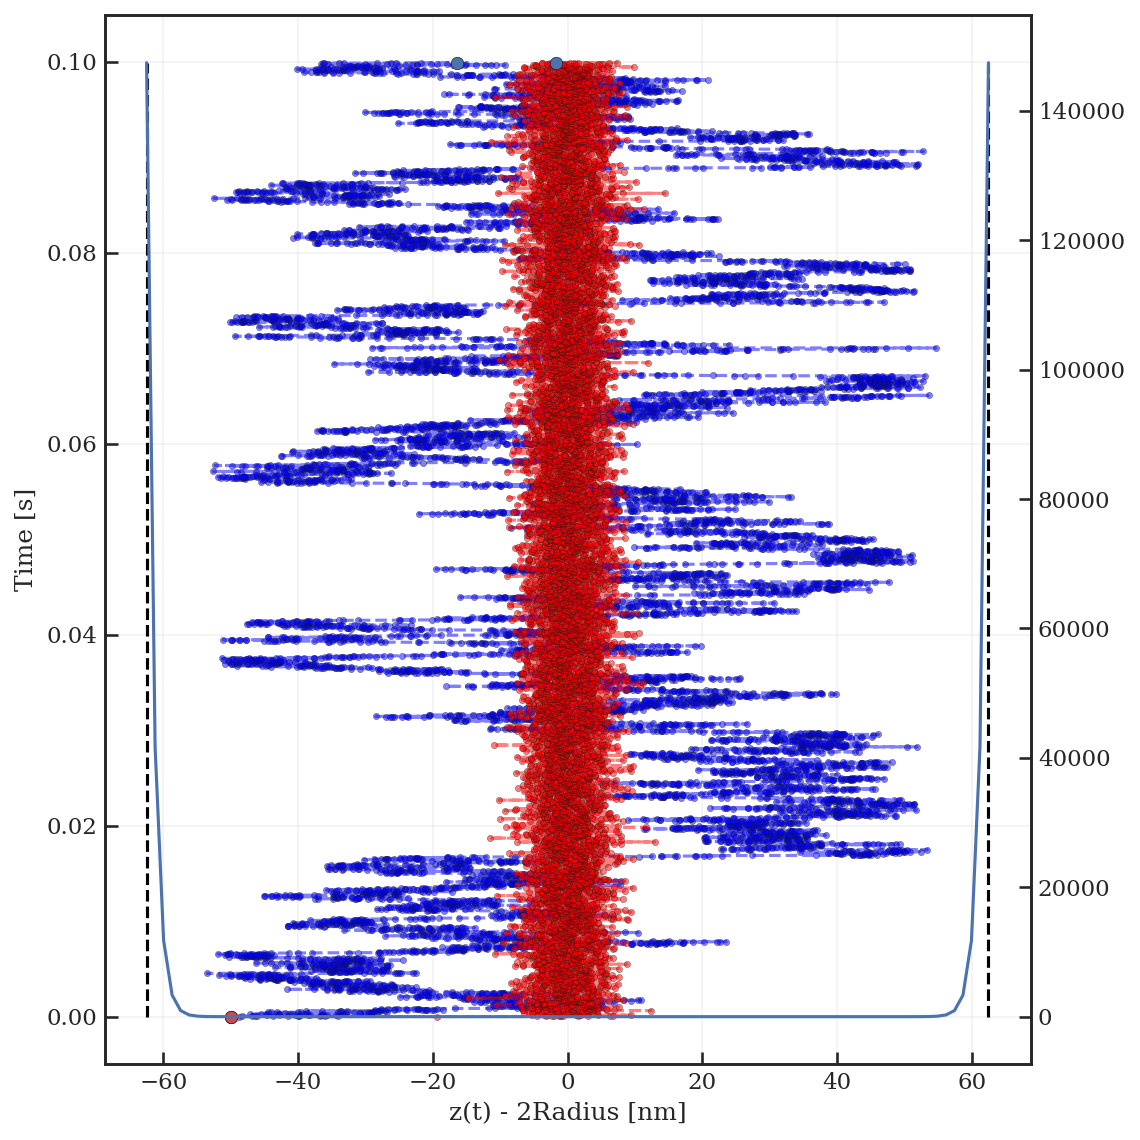

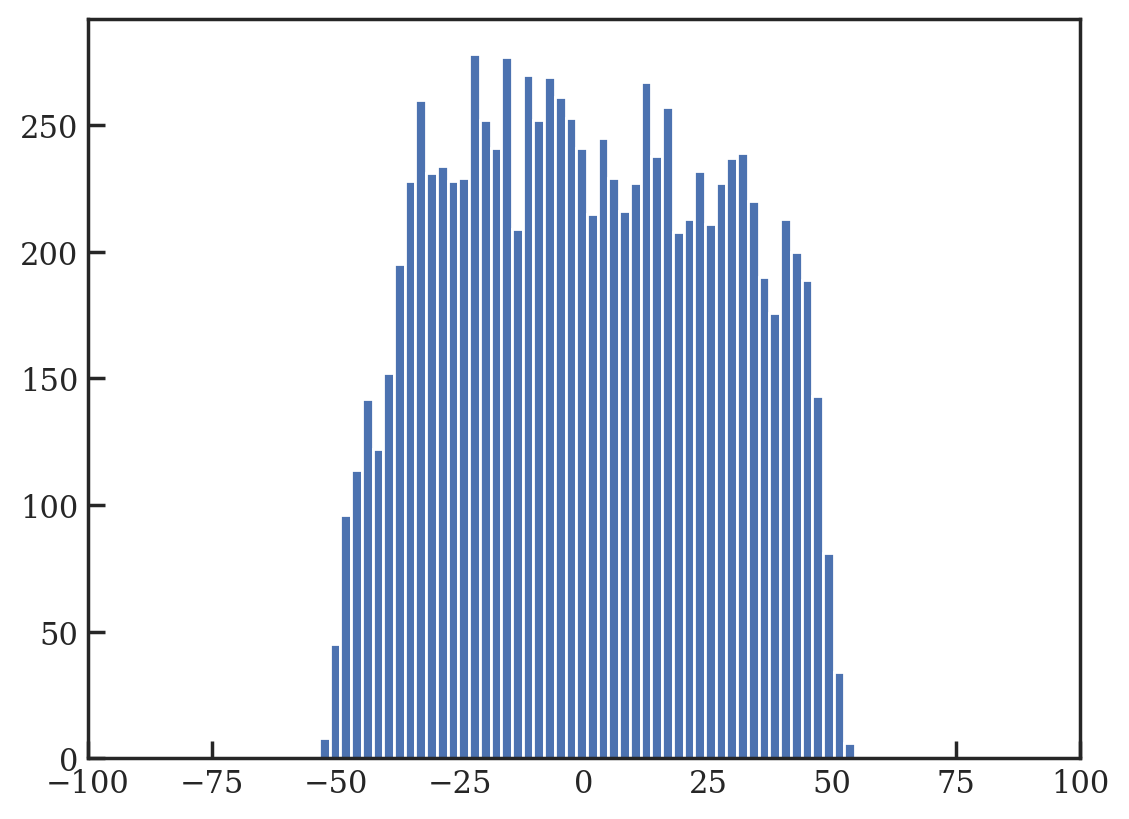

In [210]:

#plt.plot(trajx_conf*10**9)
fig = plt.figure(figsize=(8,8), dpi=150)

ax1 = fig.add_subplot(111)
#ax2 = fig.add_subplot(122)

# plot traj
trajz_conf = confined.Zn
trajz_sharp_conf = confined_sharp.Zn

trajx_conf = confined.Xn
max_n = N - 10

ax1.plot(trajz_conf[:max_n+1] * 10**9, t_conf1[:max_n +1], alpha=0.5, color='blue', linestyle='dashed', marker='o', markersize=3)
ax1.plot(trajz_conf[0] * 10**9, t_conf1[0] ,  'ro')
ax1.plot(trajz_conf[max_n] * 10**9,t_conf1[max_n], 'bo')

ax1.plot(trajz_sharp_conf[:max_n+1] * 10**9, t_conf1[:max_n +1], alpha=0.5, color='red', linestyle='dashed', marker='o', markersize=3)
ax1.plot(trajz_sharp_conf[0] * 10**9, t_conf1[0] ,  'ro')
ax1.plot(trajz_sharp_conf[max_n] * 10**9,t_conf1[max_n], 'bo')


ax1.vlines(gap * 10**9, 0, dt * max_n, color = 'black', linestyles='dashed', label='Wall')
ax1.vlines(-gap* 10**9, 0, dt * max_n, color = 'black', linestyles='dashed')
ax1.set_ylabel('Time [s]')
ax1.set_xlabel('z(t) - 2Radius [nm]')
#ax1.set_title('Confined Diffusion between Two Surfaces')
ax1.grid(alpha=0.2)

# electrostatics
def electro(z, H, lD, B):
    term1 = np.exp(-(H+z)/lD)
    term2 = np.exp(-(H-z)/lD)
    return B * (term1 + term2)

H_range = np.linspace(-gap, gap, 100)
V_pot   = electro(H_range, gap, lD, B=B)

twin2 = ax1.twinx()
p2, = twin2.plot(H_range * 10**9, V_pot, label='Electric Potential')

# #ax2.plot(H_range * 10**9, Forces(H_range, gap, kb * 293, 1e-18, lD, 1), label='MJ')
# ax2.plot(H_range * 10**9, V_pot, label='DH')
# ax2.legend()
# ax2.set_ylabel('V(z)')
# ax2.set_xlabel('x(t) [nm]')
# ax2.set_title('Electrostatic potential')

plt.tight_layout()
plt.savefig('trajectory_nice.png', transparent=True)



plt.figure()

filt_traj = trajz_conf[np.where(np.isfinite(trajz_conf))] * 10**9
print(filt_traj)

plt.hist(filt_traj, bins=50)
plt.xlim(-100, 100)
plt.show()

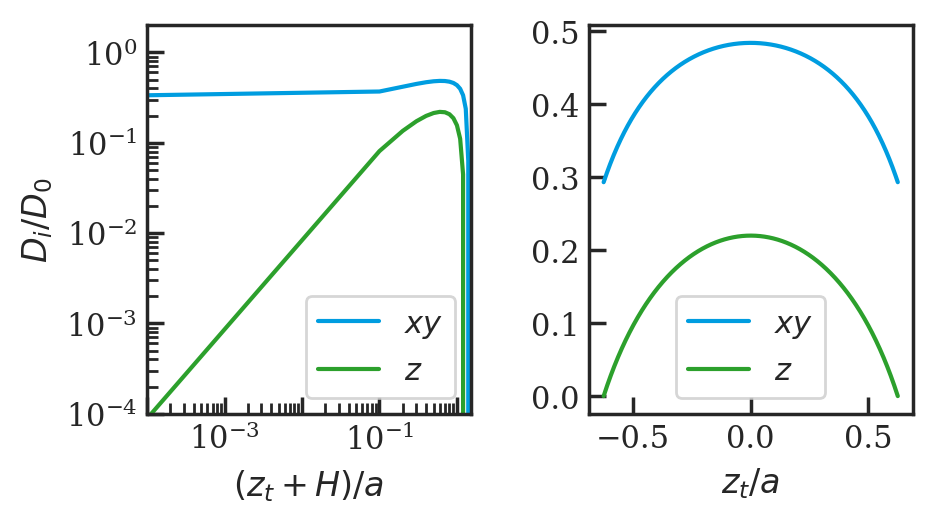

In [197]:
plt.figure(figsize=(1.5 * 3.375, 1.5 * 3.375 / 1.68), tight_layout=True)

epsilon =  confined.H*1e-8
z_1 = np.linspace(- confined.H+epsilon, - confined.H+1000e-6, 100000)
z_2 = np.linspace(- (confined.H-epsilon),  confined.H-epsilon, 1000)
D0 = confined.D0

## Diffusion à un mur
ax1 = plt.subplot(121)
ax1.loglog((z_1+ confined.H)/ confined.a,  confined.D_x(z_1)/D0, color=BlueUB, label=r'$xy$')
ax1.plot((z_1+ confined.H)/ confined.a, confined.D_z(z_1)/D0, color="tab:green", label=r'$z$')
ax1.set(
    xlabel = r"$(z_t+H)/a$",
    ylabel = r"$D_i/D_0$",
    xlim = (1e-4, 10e-1/2 + 1),
    ylim = (1e-4, 2e0),
)

from mpltools import annotation
import matplotlib as mpl

#ax1.text(0.06, 0.92, r"(a)", transform=ax1.transAxes)
locmaj = mpl.ticker.LogLocator(base=10.0, subs=(1.0, ), numticks=100)
locmin = mpl.ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * .1, numticks=100)
ax1.yaxis.set_major_locator(locmaj)
ax1.yaxis.set_minor_locator(locmin)
ax1.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

ax1.xaxis.set_major_locator(locmaj)
ax1.xaxis.set_minor_locator(locmin)
ax1.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())

ax1_ticks = ax1.get_yticklabels()
for i in ax1_ticks:
    i.set_visible(False)
for n, i in enumerate(ax1_ticks):
    if n%1==0:i.set_visible(True)
ax1_ticks = ax1.get_xticklabels()
for i in ax1_ticks:
    i.set_visible(False)
for n, i in enumerate(ax1_ticks):
    if n%2==0:i.set_visible(True)
    

## Diffusion à deux mur
ax2 = plt.subplot(122)
ax2.plot(z_2/confined.a, confined.D_x(z_2)/D0, color=BlueUB, label=r'$xy$')
ax2.plot(z_2/confined.a, confined.D_z(z_2)/D0, color="tab:green", label=r'$z$')
ax2.set(
    xlabel = r"$z_t/a$",
)
#ax2.text(0.06, 0.92, r"(b)", transform=ax2.transAxes)
plt.tight_layout()
ax1.legend()
ax2.legend()

plt.savefig('diffusiontheory.png', transparent=True)

# Theory of Electrostatics of Ionic Solutions

In [37]:
# settings
dt = 0.01 * 10**(-3) #[s]
N  = int(200) # frame number
radius  = 100e-9
gap = (225e-9 - radius)/2
B = 4.8
B0 = (B * 10**3)/dt
lD = 100 * 10**(-6)
lB = 1000         # = kb * T / g * \Delta m
T = 300
from scipy.constants import Boltzmann as kb
print(f'gap: {gap * 10**9}')
HXDD = -30e-9

# thermal forces
gamma11 = gamma_z_tot(HXDD, radius, 0.001, gap)
thermal_kick = Noise(gamma, kb*T) #* np.sqrt(dt)

# electrostatic forces
def elec(zn, H, kBT, B, lD, gamma):
    """
    @return: Total extern force on particle (without friction).
    """
    # double wall potential - derivative of the potential
    #Felec = B * (1/np.abs(H+zn)**2 + 1/np.abs(H-zn)**2)
    Felec = B * kBT/lD * np.exp(-H/lD) * (np.exp(-zn/lD) - np.exp(zn/lD))
    return Felec/gamma

e_0 = 1.602*10**(-19)   # C
zeta = -40 * 10**(-3)   # zeta potential estimate [V]
epsilon = 80 * 8.85 * 10**(-12)
potential_eff = 4  * np.tanh((e_0 * zeta)/(4 * kb * T))     # eq 10 in grier (ignoring teh kbT factor)
debye_length = 100e-6 # debye length
elec_kick = elec(HXDD, gap, kb*T, potential_eff, debye_length, gamma) / dt
print(f"Forces: \n elec: {elec_kick} \n noise: {thermal_kick}")

gap: 62.5
Forces: 
 elec: -2.4461050019809483e-08 
 noise: 2.352441948200682e-07
